<a href="https://colab.research.google.com/github/paulynamagana/AFDB_notebooks/blob/main/afdb_msa_conservation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysing AlphaFold's Database Multiple Sequence Alignments (MSAs)

## Introduction

Multiple sequence alignments (MSAs) are the primary source of evolutionary signal that AlphaFold 2 uses to predict protein structure. The Evoformer module at the core of AlphaFold 2 learns directly from patterns in the MSA, detecting which positions are invariant across species (conservation) and which positions change together in correlated ways (co-variation), to infer the three-dimensional constraints that determine a protein's fold ([Jumper et al., 2021](https://www.nature.com/articles/s41586-021-03819-2)).

The AlphaFold Database (AFDB) provides precomputed MSAs for every entry in its proteome-scale predictions, built by searching UniRef90 and MGnify with HHblits and Jackhmmer. These MSAs are available as .a3m files and represent exactly the evolutionary input that was fed to the model during prediction. Analysing them directly allows us to interrogate the evidence base behind every predicted structure and confidence score.

This notebook demonstrates how to programmatically access and analyse AFDB MSAs, with sequence conservation as the central analysis. I designed it as both a conceptual reference and a practical workflow.

## MSA Depth vs. Diversity: Why quantity is not enough

A natural assumption is that a bigger MSA is always better. This is not generally true, and understanding why, matters for interpreting both AlphaFold predictions and the analyses in this notebook.

- Depth refers to the raw number of sequences in the alignment.
- Diversity refers to how evolutionarily distinct those sequences are from one another.

A concrete illustration:
- an MSA with 5,000 sequences drawn entirely from closely related mammalian variants may be almost entirely redundant, every sequence is >98% identical to the query, contributing little independent information about which residues can tolerate change.
- In contrast, 200 sequences spanning bacteria, archaea, fungi, and vertebrates, with pairwise identities of 30–60%, encode far richer co-evolutionary signal. AlphaFold's performance is sensitive to this distinction.

A common approach to quantify the alignment depth of an MSA is by counting the normalised number of effective sequences (Neff), rather than simply reporting raw sequence count. Neff downweights near-duplicate sequences to give an estimate of the true evolutionary information content of the alignment, and is a widely used metric in structure prediction pipelines.

If you would like a clear and practical discussion of Neff (number of effective sequences) and why it matters, I recommend reading:

>   [Zhang et al., DeepMSA: constructing deep multiple sequence alignment to improve contact prediction and fold-recognition for distant-homology proteins. Bioinformatics (2020).](https://doi.org/10.1093/bioinformatics/btz863)

## What this notebook covers

This notebook walks through the following analyses in order:

1. Fetching AFDB data: querying the AlphaFold API to retrieve the predicted structure, pLDDT confidence scores, PAE matrix, and MSA for a protein of interest.
2. MSA sanity checking: visualising the alignment as an identity map relative to the query sequence, to inspect coverage and gap patterns before running any metrics.
3. MSA diversity (Neff): computing the effective number of sequences to assess how much independent evolutionary variation the alignment contains.
4. Per-residue conservation (Shannon entropy and KL divergence): calculating position-wise conservation scores, identifying the most conserved and compositionally unusual positions, and smoothing profiles for structural interpretation.


- **Note:** Conservation is necessary but not sufficient for functional annotation. A conserved residue could be critical for folding stability rather than catalysis or binding. I recommend cross-referencing with structural context, sequence/structure annotations (e.g., from UniProt or PDB), and experimental data.


In [ ]:
#@title # Import and install libraries
!pip install BioPython
!pip install py3Dmol

import numpy as np
import matplotlib.pyplot as plt
import requests
import re
from io import StringIO
from collections import Counter
from Bio import AlignIO
from Bio.PDB import PDBParser, PDBIO
import py3Dmol
import json
import seaborn as sns
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import uniform_filter1d
from matplotlib.patches import Patch
from IPython.display import display, HTML

sns.set_style('whitegrid')

print("----All packages imported successfully---")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
----All packages imported successfully---


## <font color='#077187' size=16>**Fetch the data**</font>

In [ ]:
uniprot_id = "Q92794" #@param {type:"string"}

url_pdb_prediction = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id.strip()}"

try:
    response = requests.get(url_pdb_prediction, timeout=20)
    if response.status_code == 200:
        result = response.json()
        print(json.dumps(result, indent=2))
    else:
        print(f"Error getting prediction for {uniprot_id}")
except requests.RequestException as e:
    print(f"Error during request: {e}")

[
  {
    "toolUsed": "AlphaFold Monomer v2.0 pipeline",
    "providerId": "GDM",
    "entityType": "protein",
    "isUniProt": true,
    "modelEntityId": "AF-Q92794-F1",
    "modelCreatedDate": "2025-08-01T00:00:00Z",
    "sequenceVersionDate": "2008-11-25T00:00:00Z",
    "globalMetricValue": 48.66,
    "fractionPlddtVeryLow": 0.699,
    "fractionPlddtLow": 0.03,
    "fractionPlddtConfident": 0.102,
    "fractionPlddtVeryHigh": 0.169,
    "latestVersion": 6,
    "allVersions": [
      1,
      2,
      3,
      4,
      5,
      6
    ],
    "sequence": "MVKLANPLYTEWILEAIKKVKKQKQRPSEERICNAVSSSHGLDRKTVLEQLELSVKDGTILKVSNKGLNSYKDPDNPGRIALPKPRNHGKLDNKQNVDWNKLIKRAVEGLAESGGSTLKSIERFLKGQKDVSALFGGSAASGFHQQLRLAIKRAIGHGRLLKDGPLYRLNTKATNVDGKESCESLSCLPPVSLLPHEKDKPVAEPIPICSFCLGTKEQNREKKPEELISCADCGNSGHPSCLKFSPELTVRVKALRWQCIECKTCSSCRDQGKNADNMLFCDSCDRGFHMECCDPPLTRMPKGMWICQICRPRKKGRKLLQKKAAQIKRRYTNPIGRPKNRLKKQNTVSKGPFSKVRTGPGRGRKRKITLSSQSASSSSEEGYLERIDGLDFCRDSNVSLKFNKKTKGLIDGLTKFFTPSPDGRKARGEVVDYSEQYR

In [ ]:
#@markdown This code block will print a table of all available entries for that UniProt ID, which can include isoforms.

print(f"All entries for the UniProt ID {uniprot_id}:")

rows= []

for item in result:
    modelID = item.get("modelEntityId")
    description = item.get("uniprotDescription")
    latestVersion = item.get("latestVersion")
    average_plddt = item.get("globalMetricValue")
    fractionPlddtVeryLow = item.get("fractionPlddtVeryLow")
    fractionPlddtLow = item.get("fractionPlddtLow")
    fractionPlddtConfident = item.get("fractionPlddtConfident")
    fractionPlddtVeryHigh = item.get("fractionPlddtVeryHigh")

    rows.append({
        "model_ID": modelID,
        "description":description,
        "average_plddt": average_plddt,
        "latest_version": latestVersion,
        "fractionPlddtVeryLow": "{:.1f}%".format(fractionPlddtVeryLow * 100),
        "fractionPlddtLow": "{:.1f}%".format(fractionPlddtLow* 100),
        "fractionPlddtConfident": "{:.1f}%".format(fractionPlddtConfident* 100),
        "fractionPlddtVeryHigh": "{:.1f}%".format(fractionPlddtVeryHigh* 100)
    })

df = pd.DataFrame(rows)
df

All entries for the UniProt ID Q92794:


,model_ID,description,average_plddt,latest_version,fractionPlddtVeryLow,fractionPlddtLow,fractionPlddtConfident,fractionPlddtVeryHigh
0,AF-Q92794-F1,Histone acetyltransferase KAT6A,48.66,6,69.9%,3.0%,10.2%,16.9%


In [ ]:
#@markdown Now, choose one model ID to analyse the MSA.
#@markdown This code block will first visualise the structure and the PAE plot
model = "AF-Q92794-F1"#@param {type:"string"}
plddt_url = msa_url = pdbUrl = paeDocUrl = None

for entry in result:
    if entry["modelEntityId"] == model:
        plddt_url = entry["plddtDocUrl"]
        msa_url = entry["msaUrl"]
        pdbUrl = entry["pdbUrl"]
        paeDocUrl = entry["paeDocUrl"]
        break
if not model:
    print(f"Model {model} not found in results.")
if msa_url is None:
    raise ValueError(f"Model {model} not found for UniProt ID {uniprot_id}.")

if plddt_url and msa_url:
    #print(f"--Fetching pLDDT from: {plddt_url}")
    plddt_response = requests.get(plddt_url)
    plddt_data = plddt_response.json()
    #print(plddt_data)

    plddt_scores = plddt_data['confidenceScore']
    residue_number = plddt_data['residueNumber']
    #print(f"Entry length: {len(plddt_scores)}")
    print(f"Successfully fetched pLDDT for {len(plddt_scores)} residues.")

    #print(f"--Fetching MSA from: {msa_url}")
    msa_response = requests.get(msa_url)
    msa_content = msa_response.text # Get the raw text of the .a3m file
    print("Successfully fetched MSA content.")

else:
    print(f"Error: Could not find URLs for model {model}")

def parse_a3m_content(msa_content):
    """Parses the A3M content into a list of uppercase sequences."""
    sanitised_content = re.sub(r'[a-z]', '', msa_content)

    alignment = AlignIO.read(StringIO(sanitised_content), "fasta")

    #convert to a simple list of strings
    msa_array = np.array([list(str(rec.seq)) for rec in alignment])

    return msa_array

print("Parsing A3M content...")
msa_array = parse_a3m_content(msa_content)
query_seq = msa_array[0]
print(f"Parsing complete. Found {len(msa_array)} sequences.")

Successfully fetched pLDDT for 2004 residues.
Successfully fetched MSA content.
Parsing A3M content...
Parsing complete. Found 10151 sequences.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

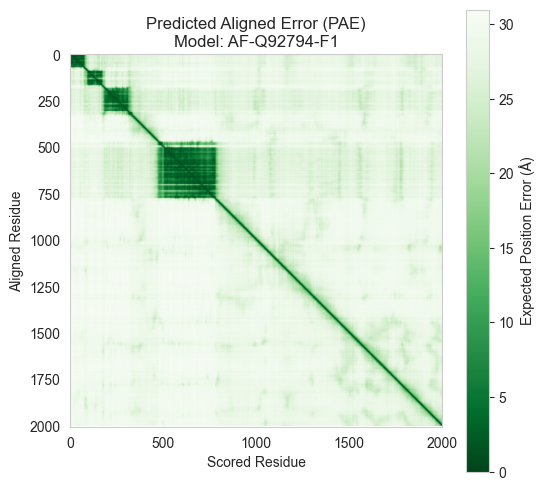

In [ ]:
#@markdown Run this cell to see the structure coloured by pLDDT and the PAE plot

# Function to show protein structure and image
def plot_pae(pae_url):
    response = requests.get(pae_url)
    data = response.json()

    if isinstance(data, list) and len(data) > 0:
        pae_matrix = data[0]['predicted_aligned_error']
    else:
        print("Invalid PAE data format.")
        return

    # Plotting
    plt.figure(figsize=(6, 6))
    plt.imshow(pae_matrix, cmap='Greens_r', vmin=0, vmax=31)

    cb = plt.colorbar()
    cb.set_label('Expected Position Error (Å)')
    plt.title(f'Predicted Aligned Error (PAE)\nModel: {model}')
    plt.xlabel('Scored Residue')
    plt.ylabel('Aligned Residue')
    plt.grid(False)
    plt.show()

def show_structure_and_image(pdb_url, paeUrl, color="plDDT"):
    pdb_data = requests.get(pdb_url).text
    # Create a 3Dmol.js view
    view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
    # Add the PDB data to the view
    view.addModel(pdb_data, 'pdb')

    if color == "plDDT":
        view.setStyle({'cartoon': {'colorscheme': {'prop': 'b', 'gradient': 'roygb', 'min': 50, 'max': 90}}})
    elif color == "rainbow":
        view.setStyle({'cartoon': {'color': 'spectrum'}})

    # Zoom to the structure
    view.zoomTo()
    display(view) # Display
    plot_pae(paeUrl) # Display

show_structure_and_image(pdbUrl, paeDocUrl, "plDDT")


# <font color='#077187' size=16>**Visual sanity check: MSA identity map**</font>

Before computing any quantitative metrics, it is good practice to visually inspect
the alignment. This plot encodes a single binary question at each position for each
sequence:

*"Does this residue match the query (the first sequence in the alignment)?"*

- **Dark**: residue matches the query at this column  
- **Light**: different residue or a gap

### What to look for

- **Coverage and gap patterns.** Large light horizontal bands indicate sequences with poor coverage of the query region, often reflecting domain insertions or deletions in those homologs, or alignment to only one domain of a multi-domain protein. Extensive gaps concentrated at the N- or C-terminus are common and generally expected.

- **Redundancy clusters.** If a dense block of nearly identical dark rows appears near the top of the map, the MSA likely contains many closely related sequences (e.g., from the same genus or species group). This is not a problem per se, but it means raw sequence count overstates the true evolutionary diversity, exactly what the Neff calculation in the next section corrects for.

- **Incoherent alignments.** If the map looks entirely random with no coherent vertical structure, the MSA may contain weakly homologous sequences, sequences from mismatched protein families, or the alignment may simply be too shallow to carry useful signal.

This plot is a quality diagnostic. Use it to confirm the alignment looks structurally reasonable, then proceed to Neff and per-residue conservation for quantitative inference.

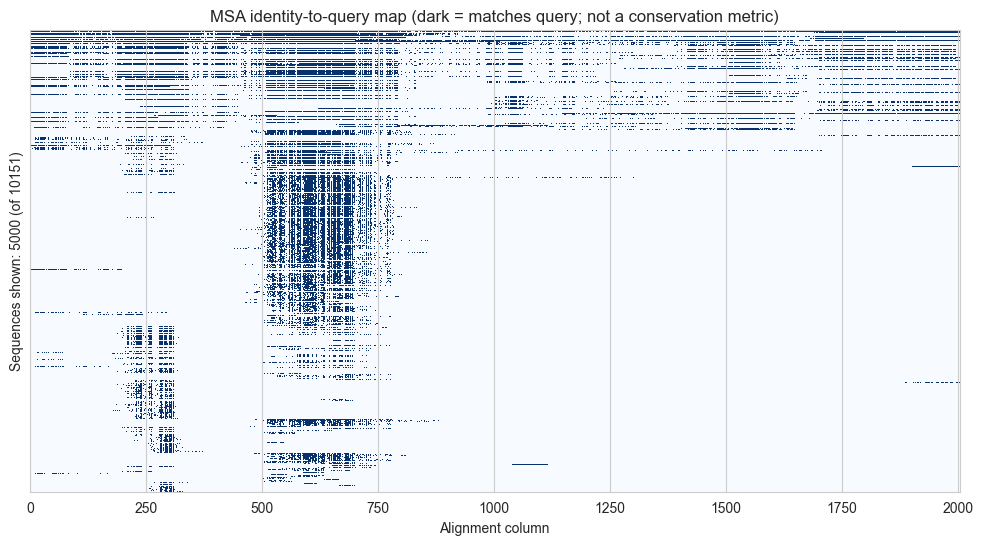

In [ ]:
#@markdown This code block will show a binary identity-to-query map for quick sanity checking of the MSA.

#@markdown - Dark = matches the query residue at that column (including '-' if present).
#@markdown - Light = mismatch.

#@markdown  Note: This is NOT a conservation plot; it's identity relative to the query.

#@markdown  If you prefer, you can change the maximum number of sequences to use here:
max_seqs = 5000 #@param {type:"number"}

def plot_msa_identity_map(msa_num, max_seqs=5000):
    """
    Binary identity-to-query map for quick sanity checking.
    Dark = matches the query residue at that column (including '-' if present).
    Light = mismatch.
    Note: This is NOT a conservation plot; it's identity relative to the query.
    """
    n_seqs = msa_num.shape[0]

    # Subsample uniformly if too large for matplotlib
    if n_seqs > max_seqs:
        indices = np.linspace(0, n_seqs - 1, max_seqs, dtype=int)
        display_msa = msa_num[indices]
        shown = max_seqs
    else:
        display_msa = msa_num
        shown = n_seqs

    query_seq = display_msa[0]
    matches = (display_msa == query_seq)

    plt.figure(figsize=(12, 6))
    plt.imshow(matches, aspect='auto', cmap='Blues', interpolation='nearest')
    plt.title("MSA identity-to-query map (dark = matches query; not a conservation metric)")
    plt.xlabel("Alignment column")
    plt.ylabel(f"Sequences shown: {shown} (of {n_seqs})")
    plt.yticks([])
    plt.show()

# Convert MSA to numbers (simple mapping for visualization)
aa_map = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY-")}
msa_num = np.array([[aa_map.get(c, 20) for c in seq] for seq in msa_array])

plot_msa_identity_map(msa_num)

## <font color='#077187' size=18>**Analysis 1 - MSA Diversity (Neff)** </font>

The identity map may show hundreds or thousands of sequences and suggest the MSA is well-populated. However, raw sequence count is a poor proxy for information content. What matters for structure prediction is not how many sequences are present, but how much independent evolutionary variation they represent.


### <font color='#f7c59f' size=18> $N_{eff}$: a diversity-aware sequence count </font>

To quantify the true information content of an MSA, we compute $N_{eff}$,  the effective number of sequences. Rather than counting all sequences equally, $N_{eff}$ assigns each sequence a weight inversely proportional to the number of near-identical neighbours it has in the alignment. Sequences with many close relatives contribute little; sequences representing unique evolutionary lineages contribute fully.

Neff is a "weighted" count. It answers the question, "How many truly distinct sequences are in this alignment?" A sequence that is highly unique gets a weight near 1.0, while a sequence that is 99% identical to 100 others gets a very low weight (e.g. 0.1). Neff is a proxy for how much non-redundant evolutionary variation is present, which is often helpful for coevolution-based inference.

Formally, the weight assigned to sequence $n$ is:

$$w_n = \frac{1}{1 + \sum_{m=1, m \neq n}^{N} \mathbb{I}[S_{m,n} \geq \theta]}$$

The raw $N_{eff}$ is then the sum of all weights across the alignment:

$$N_{\text{eff}}^{\text{raw}} = \sum_{n=1}^{N} w_n$$

Where:
- $L$ is the length of the query protein
- $N$ is the number of sequences in the MSA
- $S_{m,n}$ is the pairwise sequence identity between sequences $m$ and $n$, computed only over positions where both sequences are non-gap. This gap-aware calculation prevents shared deletions from inflating apparent similarity.
- $\theta$ is the redundancy threshold. The conventional value is **0.8 (80%)**. Sequence pairs with fewer than 30 shared non-gap positions are treated as non-redundant regardless of identity, as there is insufficient overlap for a reliable estimate.
- The $1 +$ in the denominator counts the sequence itself, ensuring the minimum possible weight is $1/(1 + N - 1) = 1/N$ rather than undefined. This is the convention used in the trRosetta and RaptorX literature [Yang et al., 2020].
- $\mathbb{I}[\cdot]$ is the Iverson bracket: equal to 1 if the condition is satisfied, 0 otherwise.


Read more about it here :
 > [**Wu, T. et al. (2020)** *Analysis of several key factors influencing deep learning-based inter-residue contact prediction.* Bioinformatics.](https://doi.org/10.1093/bioinformatics/btz679) <br>
An excellent, systematic breakdown of how factors like MSA depth, alignment algorithms, and sequence weighting impact deep learning models.

 > [**Pearce, Robin et al. (2021)** *Toward the solution of the protein structure prediction problem.* Journal of Biological Chemistry](https://www.jbc.org/article/S0021-9258(21)00670-0/fulltext).<br>
A comprehensive review of the evolution of structure prediction, including a clear analysis of how contact prediction accuracy improved across CASP experiments and how that related to MSA depth, coevolution, and the transition to deep learning and end-to-end models.

I also recommend you to read the Supporting Information from this paper, where they illustrate the mathematical meaning of Neff:
 >  **Zhang, C. et al., (2020)** [DeepMSA: constructing deep multiple sequence alignment to improve contact prediction and fold-recognition for distant-homology proteins](https://doi.org/10.1093/bioinformatics/btz863)

### Normalisation by alignment length

A raw $N_{eff}$ of 500 means something different for a 100-residue protein than for a  2,000-residue one: longer proteins have more positions to constrain and require  proportionally more diverse sequences to sample their co-evolutionary space. To make $N_{eff}$ comparable across proteins of different lengths, we normalise by the square root of alignment length $L$:

$$N_{\text{eff}} = \frac{N_{\text{eff}}^{\text{raw}}}{\sqrt{L}}$$


### Interpreting $N_{eff}$ / √L

The two limiting cases make the behaviour of $N_{eff}$ intuitive:

- **Maximum diversity** (all pairwise identities < 0.8): every sequence is unique, the inner sum is 0 for all $n$, and $N_{\text{eff}} = N / \sqrt{L}$.
$N_{eff}$ scales directly with the number of sequences.

- **Maximum redundancy** (all pairwise identities ≥ 0.8): every sequence is near-identical to all others, the inner sum equals $N - 1$ for all $n$, and $N_{\text{eff}} = 1 / \sqrt{L}$ regardless of how many sequences are present. The entire alignment contributes no more information than a single sequence.


In [ ]:
#@title Calculating Neff

#@markdown subsample cap — reduce if Colab times out
MAX_SEQS = 4000 # @param {"type":"number"}
#  The pairwise identity matrix scales as O(N²). For large MSAs (N > ~4,000) this becomes slow on standard hardware and may
#  exhaust memory on Google Colab. When the MSA exceeds max_seqs,
#  a random subsample is drawn instead and the result is flagged
#  as approximate. The query sequence (row 0) is always retained.
#  Adjust max_seqs if you have more RAM available, or reduce it
#  further if the cell is still timing out.

 #@markdown sequence identity threshold for redundancy clustering
THRESHOLD  = 0.80   # @param {"type":"number"}

#@markdown  minimum shared non-gap positions to call a valid identity
MIN_OVERLAP = 30    # @param {"type":"number"}


RANDOM_SEED = 42

AA20 = "ACDEFGHIKLMNPQRSTVWY"

def _encode_msa(msa_array, gap_char='-'):
    """
    Encode an MSA (N,L) of single-character strings into int16 codes.
    AA20 → 0-19
    Non-standard → 20
    gap → -1
    """

    msa = np.asarray(msa_array)
    if msa.dtype.kind not in ("U", "S", "O"):
        raise ValueError("msa_array should contain single-character residues (e.g., dtype '<U1').")

    mapping = {aa: i for i, aa in enumerate(AA20)}
    other_code = 20
    gap_code = np.int16(-1)

    def _enc(x):
        if x == gap_char:
            return gap_code
        return np.int16(mapping.get(x, other_code))

    return np.vectorize(_enc, otypes=[np.int16])(msa_array), gap_code


def compute_neff(msa_int, gap_code, threshold=0.8, min_overlap=30):
    ## Pairs with <30 shared non-gap positions are treated as not similar.
    """

    Compute N_eff following the definition in Zheng, W. et al., 2024. https://doi.org/10.1038/s41592-023-02130-4

    where identity is computed only over positions where both
    sequences are non-gap (gap-aware), and pairs with fewer than
    min_overlap shared positions are treated as non-redundant
    (distance = 1.0) — a conservative choice when overlap is
    insufficient for a reliable identity call.

    Returns
    -------
    neff_raw    : float  — unnormalised Σ w_n  (used as sequence weights
                          in downstream conservation calculations)
    neff_sqrtL  : float  — neff_raw / √L  (the quantity reported in the
                          literature; length-independent and comparable
                          across proteins)
    weights     : ndarray shape (N,) — per-sequence weights w_n, where
                  w_n = 1 / (1 + number of sequences with id ≥ θ,
                  excluding self)
    """

    N, L = msa_int.shape

    def _gap_aware_hamming(u, v):
        # u, v are 1D arrays length L
        mask = (u != gap_code) & (v != gap_code)
        overlap = int(mask.sum())
        if overlap < min_overlap:
            return 1.0  # insufficient overlap → treat as dissimilar
        matches = int(((u == v) & mask).sum())
        ident = matches / overlap
        return 1.0 - ident

    # Condensed pairwise distances (size ~ N*(N-1)/2)
    dist = squareform(pdist(msa_int, metric=_gap_aware_hamming))

    # Count neighbours above threshold, EXCLUDING self (matching paper formula)
    # dist diagonal is 0.0, so threshold comparison would include self —
    # we zero the diagonal of the similarity matrix explicitly before summing
    similar_excl_self = dist <= (1.0 - threshold)
    np.fill_diagonal(similar_excl_self, False)

    # w_n = 1 / (1 + number of sequences with id >= threshold, m≠n)
    neighbour_counts = similar_excl_self.sum(axis=1).astype(np.float64)
    weights          = 1.0 / (1.0 + neighbour_counts)

    neff_raw   = float(weights.sum())
    neff_sqrtL = neff_raw / np.sqrt(L)

    return neff_raw, neff_sqrtL, weights


# Ensure msa_array is (N, L) of single characters
if isinstance(msa_array, (list, tuple)) and isinstance(msa_array[0], str):
    msa_chars = np.array([list(s) for s in msa_array], dtype="<U1")
else:
    msa_chars = np.asarray(msa_array)

    if msa_chars.ndim != 2:
        raise ValueError("Expected msa_array as list of aligned strings or a (N,L) character array.")


N_raw, L = msa_chars.shape
## subsampling for large MSAs ---#
if N_raw > MAX_SEQS:
    rng = np.random.default_rng(RANDOM_SEED)
    other_idx = rng.choice(np.arange(1, N_raw), size=MAX_SEQS-1, replace=False)
    sample_idx = np.concatenate(([0], other_idx))  # always include query (index 0)
    msa_use = msa_chars[sample_idx]
    print(f"MSA has {N_raw} sequences; subsampling to {MAX_SEQS} for Neff calculation (approximate).")
    is_approx = True
else:
    msa_use = msa_chars
    print(f"MSA has {N_raw} sequences; using all for Neff calculation.")
    is_approx = False

N_used = msa_use.shape[0]



# Compute Neff
print("Computing Neff...this may take a moment for large MSAs.")

msa_int, gap_code = _encode_msa(msa_use)
neff, neff_sqrtL, weights = compute_neff(msa_int, gap_code,
                                         threshold=THRESHOLD,
                                         min_overlap=MIN_OVERLAP)

neff_over_N = neff / N_used


print(f"{'-'*30}")
print(f"Raw sequences (N): {N_raw: >8,}")
if is_approx:
    print(f"Sequences used for Neff (N_used): {N_used: >8,} (subsampled)")
else:
    print(f"Sequences used for Neff (N_used): {N_used: >8,} (all)")
print(f"Alignment length (L): {L: >8,}")

print(f"{'-'*30}")
print(f"N_eff (raw): {neff: >8.2f}")
print(f"N_eff / N : {neff_over_N: >8.2f}")
print(f"N_eff / √L: {neff_sqrtL: >8.2f}")

print(f"{'-'*30}")



MSA has 10151 sequences; using all for Neff calculation.
Computing Neff...this may take a moment for large MSAs.
------------------------------
Raw sequences (N):   10,151
Sequences used for Neff (N_used):   10,151 (all)
Alignment length (L):    2,004
------------------------------
N_eff (raw):  2271.67
N_eff / N :     0.22
N_eff / √L:    50.75
------------------------------


### Interpreting the three $N_{eff}$ metrics

The three values reported above capture different aspects of MSA quality and should be read together rather than in isolation.

Crucially, the relationship between $N_{eff}$ and prediction quality is **probabilistic, not deterministic**. Some proteins with a low $N_{eff}$ are predicted exceptionally well (particularly short, physically well-constrained domains or those with known PDB entries that were used for training deep learning or for inference), while some with a high $N_{eff}$ still yield poor predictions (such as intrinsically disordered regions, or multi-domain proteins with highly flexible linkers).

---

**1. $N_{eff}$ (raw)**
The total effective number of sequences after downweighting redundant neighbours. This is an absolute count with no correction for protein length, so it is not directly comparable across proteins of different sizes. Its main use in this notebook is as the basis for per-sequence weights passed to the conservation calculation; it is an input to downstream analysis rather than a standalone "quality" metric.

Deeper alignment with more diverse homologous sequences (higher Neff) usually results in higher contact prediction precision for deep learning predictors, because of the coevolutionary input features. ([Wu, T. et al., February 2020](https://doi.org/10.1093/bioinformatics/btz679))

**2. $N_{eff} / N$ — The redundancy ratio**
This is the fraction of sequences that are contributing genuinely independent information. It answers the question: *"How much of my MSA is non-redundant?"*
This ratio is the an useful diagnostic for understanding *why* $N_{eff}$ diverges from raw $N$. A value of 0.31, for example, tells you that roughly 70% of your sequences are near-duplicates of something else already in the alignment, the MSA looks deep, but is far less informative than its raw size suggests.

**3. $N_{eff} / \sqrt{L}$ — The length-normalised depth**
Because longer proteins require more evolutionary data to accurately resolve complex, long-range 3D contacts, raw $N_{eff}$ must be scaled by the protein's length ($L$). This normalised metric allows you to compare the evolutionary depth of a tiny 50-amino-acid peptide against a massive 2000-amino-acid protein on equal footing.

---


### Recommended Reading on MSA Depth

Because the relationship between $N_{eff}$ and prediction accuracy depends heavily on the specific architecture of the protein, there is no single universally agreed-upon "magic threshold." The common rule-of-thumb that $N_{eff} \approx 30$ represents a critical "danger zone" stems from early co-evolution algorithms and AlphaFold's own benchmarks, but modern deep learning models are increasingly capable of extrapolating from shallower alignments using learnt physical heuristics.

If you wish to explore the mathematics and benchmarks behind MSA depth and structural prediction, I highly recommend the following papers:

#### The Foundations of Co-evolution (Pre-Deep Learning)
Before deep learning, Direct Coupling Analysis (DCA) relied purely on statistical physics to extract structural contacts from MSAs. These papers establish the historical baselines for sequence depth requirements:

> **Ovchinnikov, S. et al. (2017)** *Protein structure determination using metagenome sequence data.* Science.<br>
  This paper established the widely cited pre-deep learning heuristic that an MSA needed an $N_{eff}/L > 64$ to reliably predict a 3D structure.
  
> **Marks, D.S. et al. (2011)** *Protein 3D structure computed from evolutionary sequence variation.* PLoS One.<br>
  A foundational paper explaining exactly how evolutionary constraints (co-variation) are extracted from MSAs to compute 3D folds.

> **Jumper, J. et al. (2021)** *Highly accurate protein structure prediction with AlphaFold.* Nature.<br>
  The definitive source for AlphaFold 2. **Figure 5a** specifically maps the logarithmic relationship between median MSA depth and backbone accuracy, showing a steep performance drop-off below an $N_{eff}$ of ~30 for proteins lacking homologous templates in the PDB.

> **del Alamo, D. et al. (2022)** *Sampling alternative conformational states of transporters and receptors with AlphaFold2.* eLife.<br>
  A demonstration that having a massive $N_{eff}$ isn't always the goal. The authors show that deliberately *reducing* MSA depth (using shallow MSAs) can force AlphaFold to predict alternative functional conformations of a protein rather than just a single state.

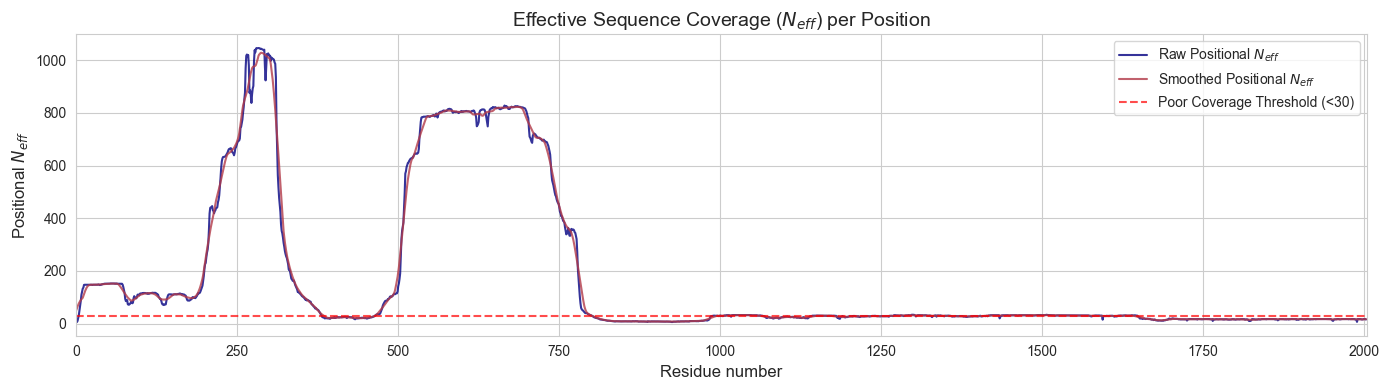

In [ ]:
# @title Calculate and Plot Neff Per Position

is_residue = (msa_use != "-")
per_pos_neff = weights @ is_residue.astype(np.float64)  # shape (L,)

#retrieve pLDDT for query sequence (row 0)
plddt = np.array(plddt_scores)

#check that lengths match
assert len(per_pos_neff) == len(plddt), (
    f"Length mismatch: per_pos_neff={len(per_pos_neff)}, plddt={len(plddt)}"
)

def nan_aware_smooth(y, window=15):
    """
    Box-kernel smoothing that ignores NaN positions.
    NaN positions contribute neither signal nor weight to
    their neighbours, so low-coverage or masked columns
    do not distort the profile around them.
    """
    y = np.asarray(y, dtype=float)
    y_filled = np.where(np.isfinite(y), y, 0.0)
    valid    = np.isfinite(y).astype(float)
    kernel   = np.ones(window) / window

    smoothed_num   = np.convolve(y_filled, kernel, mode='same')
    smoothed_denom = np.convolve(valid,    kernel, mode='same')

    with np.errstate(invalid='ignore'):
        result = np.where(smoothed_denom > 0,
                          smoothed_num / smoothed_denom,
                          np.nan)
    return result


# Smooth the data for visualization (e.g., using a 20-residue rolling window)
window_size = 20
smoothed_neff = nan_aware_smooth(per_pos_neff, window=window_size)

# 3. Plot the result
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(per_pos_neff, alpha=0.8, color="#020081", label='Raw Positional $N_{eff}$')
ax.plot(smoothed_neff, alpha=0.8, color="#B23A48", label='Smoothed Positional $N_{eff}$')

# Add a horizontal line marking a "low coverage" threshold (e.g., Neff = 30)
ax.axhline(30, color='red', linestyle='--', alpha=0.7, label='Threshold ($N_{eff}$<30)')

ax.set_xlim(0, L)
ax.set_xlabel('Residue number', fontsize=12)
ax.set_ylabel('Positional $N_{eff}$', fontsize=12)
ax.set_title('Effective Sequence Coverage ($N_{eff}$) per Position', fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

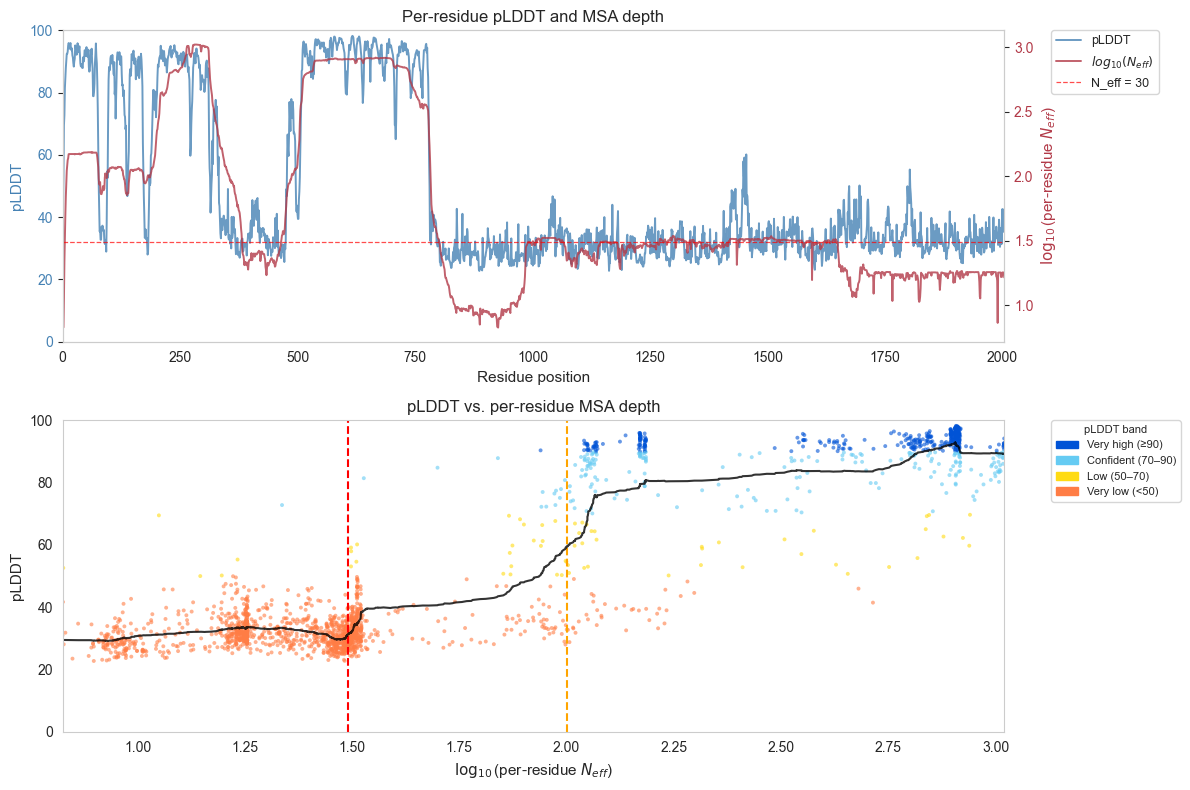

In [ ]:
#@markdown Plot $N_{eff}$ with pLDDT and MSA depth agains pLDDT
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

residue_idx = np.arange(1, len(plddt) + 1)
ax1 = axes[0]
ax2 =ax1.twinx()

ax1.plot(residue_idx, plddt, color='steelblue', lw=1.4, alpha=0.8, label='pLDDT')
ax1.set_xlabel('Residue position', fontsize=11)
ax1.set_ylabel('pLDDT', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 100)

ax2.plot(residue_idx, np.log10(per_pos_neff + 1), color="#B23A48",
         lw=1.4, alpha=0.8, label=r'$log_{10}(N_{eff})$')
ax2.axhline(np.log10(31),  color='red',   lw=0.9, ls='--', alpha=0.7,
            label='N_eff = 30')

ax2.set_ylabel(r"$\log_{10}$(per-residue $N_{eff}$)", color="#B23A48", fontsize=11)
ax2.tick_params(axis='y', labelcolor="#B23A48")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9,
           loc='upper left',                # anchor point inside legend box
          bbox_to_anchor=(1.05, 1),        # position outside axes (right side)
          borderaxespad=0)
ax1.set_title('Per-residue pLDDT and MSA depth', fontsize=12)
ax1.grid(False)
ax2.grid(False)
ax2.set_xlim(0, len(plddt))

# --- Second plot: scatter pLDDT vs log10(per-residue N_eff) ------------
ax = axes[1]

# Colour points by pLDDT band (AF2 convention)
colors = np.where(plddt >= 90, '#0053D6',        # very high
         np.where(plddt >= 70, '#65CBF3',         # confident
         np.where(plddt >= 50, '#FFDB13',         # low
                               '#FF7D45')))        # very low

sc = ax.scatter(np.log10(per_pos_neff + 1), plddt,
                c=colors, alpha=0.6, s=8, linewidths=0)

# AlphaFold thresholds
ax.axvline(np.log10(31),  color='red',    lw=1.5, ls='--',
           label='N_eff = 30')
ax.axvline(np.log10(101), color='orange', lw=1.5, ls='--',
           label=r'$N_{eff}$ = 100')

# Smoothed trend line
from scipy.ndimage import uniform_filter1d
sort_idx   = np.argsort(per_pos_neff)
x_sorted   = np.log10(per_pos_neff[sort_idx] + 1)
y_sorted   = plddt[sort_idx]
y_smoothed = uniform_filter1d(y_sorted.astype(float), size=max(1, len(y_sorted)//10)) # smooth over 10% of the length
ax.plot(x_sorted, y_smoothed, color='black', lw=1.5, alpha=0.8,
        label='Smoothed trend')

ax.set_xlabel(r"$\log_{10}$(per-residue $N_{eff}$)", fontsize=11)
ax.set_ylabel('pLDDT', fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('pLDDT vs. per-residue MSA depth', fontsize=12)
ax.legend(fontsize=9,
          loc='upper left')
ax.set_xlim(np.log10(per_pos_neff.min() + 1), np.log10(per_pos_neff.max() + 1))
ax.grid(False)

# pLDDT band legend (manual)
from matplotlib.patches import Patch
band_legend = [
    Patch(color='#0053D6', label='Very high (≥90)'),
    Patch(color='#65CBF3', label='Confident (70–90)'),
    Patch(color='#FFDB13', label='Low (50–70)'),
    Patch(color='#FF7D45', label='Very low (<50)'),
]
ax.legend(handles=band_legend,
          fontsize=8,
          loc='upper left',                # anchor point inside legend box
          bbox_to_anchor=(1.05, 1),        # position outside axes (right side)
          borderaxespad=0,
          title='pLDDT band',
          title_fontsize=8)

plt.tight_layout()
plt.show()

#### Top panel

Read this as a **co-registration of evolutionary support and structural confidence** along the sequence. The red line shows the $\log_{10}$ of per-residue $N_{eff}$. Whereas the blue line shows the per-residue pLDDT.

#### Bottom panel

This panel shows the same data as the previous plot but as a distribution rather than a sequence profile, making the overall relationship between MSA depth and confidence easier to assess. The trend line summarises the average pLDDT at each depth level.
The red dotted line marks where $N_{eff}$ is 30. And the yellow dotted line marks where $N_{eff}$ is 100.

#### What not to conclude

- A high per-residue $N_{eff}$ does not mean a region is correctly predicted. It means it is well-supported by evolutionary data. Always cross-check with the PAE plot for domain-level confidence.
- A low pLDDT does not always mean the region is unstructured, it may adopt a stable conformation only in the context of a binding partner or post-translational modification not captured in the MSA.
- These plots describe the **evidence available to AlphaFold**, not the ground truth of the protein's behaviour.